# 04 — Drift Analysis

Computes the full temporal drift report from the processed data, trained models, and SHAP outputs.

**Input:** `data/processed/`, `data/windows/`, `data/models/`, `data/shap/`  
**Output:** `data/results/drift_metrics.csv` and summary figures in `data/results/`


In [1]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas==2.2.2

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 770.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 47.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you 

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


> **Setup note:** this notebook requires the `rbo` package for rank-biased overlap metrics.


In [2]:
%pip install -q rbo joblib pyarrow scikit-learn


In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import wasserstein_distance
from itertools import combinations

import rbo

WORKSPACE   = Path('/content/drive/MyDrive/Home Insurance MLP')
PROC_DIR    = WORKSPACE / 'data' / 'processed'
WIN_DIR     = WORKSPACE / 'data' / 'windows'
MODEL_DIR   = WORKSPACE / 'data' / 'models'
SHAP_DIR    = WORKSPACE / 'data' / 'shap'
RESULTS_DIR = WORKSPACE / 'data' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RBO_P = 0.9
EPS   = 1e-8

print('Imports OK')


Imports OK


In [4]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names     = feature_names_json['all']
num_feature_names = feature_names_json['num']

num_col_idx = [feature_names.index(fn) for fn in num_feature_names]
bin_col_idx = [i for i in range(len(feature_names)) if i not in set(num_col_idx)]

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']
n_features = len(feature_names)

print(f'X: {X.shape}, features: {n_features}, R={R}, pairs: {len(pairs)}')
print(f'Numeric: {len(num_col_idx)}, Binary: {len(bin_col_idx)}')


X: (260753, 317), features: 317, R=5, pairs: 5
Numeric: 280, Binary: 37


## Distance and RBO helper functions


In [5]:
def cosine_distance(u: np.ndarray, v: np.ndarray) -> float:
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u < 1e-12 and norm_v < 1e-12:
        return 0.0
    if norm_u < 1e-12 or norm_v < 1e-12:
        return np.nan
    return float(1.0 - np.dot(u, v) / (norm_u * norm_v))


def rbo_distance(u: np.ndarray, v: np.ndarray, p: float = RBO_P) -> float:
    u_zero = np.all(np.abs(u) < 1e-12)
    v_zero = np.all(np.abs(v) < 1e-12)
    if u_zero and v_zero:
        return 0.0
    if u_zero or v_zero:
        return np.nan
    rank_u = list(np.argsort(-np.abs(u)))
    rank_v = list(np.argsort(-np.abs(v)))
    score = rbo.RankingSimilarity(rank_u, rank_v).rbo(p=p)
    return float(1.0 - score)


def instance_dynamic_drift(phi_A_i: np.ndarray, phi_B_i: np.ndarray, dist_fn) -> float:
    mu_A = np.nanmean(phi_A_i, axis=0)
    mu_B = np.nanmean(phi_B_i, axis=0)
    return dist_fn(mu_A, mu_B)


def instance_baseline_instability(phi_i: np.ndarray, dist_fn) -> float:
    vals = []
    for a, b in combinations(range(phi_i.shape[0]), 2):
        vals.append(dist_fn(phi_i[a], phi_i[b]))
    return float(np.nanmedian(vals)) if len(vals) else np.nan


def global_importance(phi: np.ndarray) -> np.ndarray:
    return np.abs(phi).mean(axis=(0, 1))


## Main drift computation loop


In [6]:
results = []

for p in pairs:
    pid      = p['pair_id']
    pair_dir = MODEL_DIR / f'pair_{pid:02d}'
    shap_dir = SHAP_DIR  / f'pair_{pid:02d}'

    print(f'\n── Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]} ──')

    pred_data = np.load(pair_dir / 'predictions.npz')
    shap_A    = np.load(shap_dir / 'shap_A.npy')
    shap_B    = np.load(shap_dir / 'shap_B.npy')

    idx_A    = np.array(p['idx_A'],    dtype=np.int64)
    idx_B    = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    flagged_local_idx = pred_data['flagged_idx'].astype(np.int64)
    explained_idx_path = shap_dir / 'explained_local_idx.npy'
    if explained_idx_path.exists():
        explained_local_idx = np.load(explained_idx_path).astype(np.int64)
    else:
        explained_local_idx = flagged_local_idx

    n_flagged_total = len(flagged_local_idx)
    n_flagged_explained = shap_A.shape[1]

    row = {
        'pair_id':              pid,
        'step_label_A':         p['step_label_A'],
        'step_label_B':         p['step_label_B'],
        'n_train_A':            p['n_train_A'],
        'n_train_B':            p['n_train_B'],
        'n_eval':               p['n_eval'],
        'n_flagged':            n_flagged_total,
        'n_flagged_explained':  n_flagged_explained,
        'pr_auc_A':             float(pred_data['pr_auc_A'][0]),
        'pr_auc_B':             float(pred_data['pr_auc_B'][0]),
    }

    loss_A = 1.0 - float(pred_data['pr_auc_A'][0])
    loss_B = 1.0 - float(pred_data['pr_auc_B'][0])
    row['delta_perf'] = loss_A - loss_B

    mean_Y_A = Y[idx_A].mean()
    mean_Y_B = Y[idx_B].mean()
    row['delta_Y'] = abs(mean_Y_A - mean_Y_B)
    print(f'  Target drift: {row["delta_Y"]:.4f}  (base rate A={mean_Y_A:.4f}, B={mean_Y_B:.4f})')

    X_A_raw = X[idx_A]
    X_B_raw = X[idx_B]
    reference_preprocessor = joblib.load(pair_dir / 'reference_preprocessor.joblib')

    X_A_num_sc = reference_preprocessor['qt'].transform(X_A_raw[:, num_col_idx]).astype(np.float32)
    X_B_num_sc = reference_preprocessor['qt'].transform(X_B_raw[:, num_col_idx]).astype(np.float32)

    w1_per_feat = np.zeros(n_features, dtype=np.float64)
    for k, j in enumerate(num_col_idx):
        w1_per_feat[j] = wasserstein_distance(X_A_num_sc[:, k], X_B_num_sc[:, k])
    for j in bin_col_idx:
        w1_per_feat[j] = wasserstein_distance(X_A_raw[:, j], X_B_raw[:, j])

    row['delta_X'] = float(w1_per_feat.mean())
    print(f'  Covariate drift: {row["delta_X"]:.4f}')

    stoch_path = shap_dir / 'stochasticity.json'
    if stoch_path.exists():
        with open(stoch_path) as f:
            stoch_data = json.load(f)
        row['shap_stochasticity'] = stoch_data['max_abs_diff'] if stoch_data['max_abs_diff'] is not None else np.nan
    else:
        row['shap_stochasticity'] = np.nan

    if n_flagged_explained == 0:
        for key in ['loc_cos', 'loc_rbo', 'base_cos_A', 'base_cos_B', 'base_rbo_A',
                    'base_rbo_B', 'sigma_cos', 'sigma_rbo',
                    'drift_ratio_cos', 'drift_ratio_rbo', 'global_rbo']:
            row[key] = np.nan
        results.append(row)
        continue

    dyn_cos_per_instance = []
    dyn_rbo_per_instance = []

    for i in range(n_flagged_explained):
        phi_A_i = shap_A[:, i, :]
        phi_B_i = shap_B[:, i, :]
        dyn_cos_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, cosine_distance))
        dyn_rbo_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, rbo_distance))

    dyn_cos_arr = np.array(dyn_cos_per_instance)
    dyn_rbo_arr = np.array(dyn_rbo_per_instance)

    row['loc_cos'] = float(np.nanmedian(dyn_cos_arr))
    row['loc_rbo'] = float(np.nanmedian(dyn_rbo_arr))

    base_cos_A_per = []
    base_cos_B_per = []
    base_rbo_A_per = []
    base_rbo_B_per = []

    for i in range(n_flagged_explained):
        phi_A_i = shap_A[:, i, :]
        phi_B_i = shap_B[:, i, :]
        base_cos_A_per.append(instance_baseline_instability(phi_A_i, cosine_distance))
        base_cos_B_per.append(instance_baseline_instability(phi_B_i, cosine_distance))
        base_rbo_A_per.append(instance_baseline_instability(phi_A_i, rbo_distance))
        base_rbo_B_per.append(instance_baseline_instability(phi_B_i, rbo_distance))

    row['base_cos_A'] = float(np.nanmedian(np.array(base_cos_A_per)))
    row['base_cos_B'] = float(np.nanmedian(np.array(base_cos_B_per)))
    row['base_rbo_A'] = float(np.nanmedian(np.array(base_rbo_A_per)))
    row['base_rbo_B'] = float(np.nanmedian(np.array(base_rbo_B_per)))

    row['sigma_cos'] = float(np.nanmean([row['base_cos_A'], row['base_cos_B']]))
    row['sigma_rbo'] = float(np.nanmean([row['base_rbo_A'], row['base_rbo_B']]))

    row['drift_ratio_cos'] = float(row['loc_cos'] / (row['sigma_cos'] + EPS))
    row['drift_ratio_rbo'] = float(row['loc_rbo'] / (row['sigma_rbo'] + EPS))

    global_A = global_importance(shap_A)
    global_B = global_importance(shap_B)
    row['global_rbo'] = float(1.0 - rbo.RankingSimilarity(
        list(np.argsort(-global_A)),
        list(np.argsort(-global_B))
    ).rbo(p=RBO_P))

    results.append(row)

    print(f'  Loc drift (cos): {row["loc_cos"]:.4f}  (rbo): {row["loc_rbo"]:.4f}')
    print(f'  Drift ratio (cos): {row["drift_ratio_cos"]:.4f}  (rbo): {row["drift_ratio_rbo"]:.4f}')
    print(f'  Global RBO distance: {row["global_rbo"]:.4f}')



── Pair 00: A_end=2013-08  B_end=2013-10 ──
  Target drift: 0.0017  (base rate A=0.2025, B=0.2042)
  Covariate drift: 0.0400
  Loc drift (cos): 0.0612  (rbo): 0.3896
  Drift ratio (cos): 0.3220  (rbo): 0.8399
  Global RBO distance: 0.1626

── Pair 01: A_end=2013-12  B_end=2014-02 ──
  Target drift: 0.0095  (base rate A=0.2039, B=0.1944)
  Covariate drift: 0.0356
  Loc drift (cos): 0.0492  (rbo): 0.4197
  Drift ratio (cos): 0.2429  (rbo): 0.7985
  Global RBO distance: 0.1009

── Pair 02: A_end=2014-04  B_end=2014-06 ──
  Target drift: 0.0034  (base rate A=0.1890, B=0.1855)
  Covariate drift: 0.0350
  Loc drift (cos): 0.0571  (rbo): 0.4897
  Drift ratio (cos): 0.3053  (rbo): 0.9401
  Global RBO distance: 0.1417

── Pair 03: A_end=2014-08  B_end=2014-10 ──
  Target drift: 0.0002  (base rate A=0.1779, B=0.1777)
  Covariate drift: 0.0409
  Loc drift (cos): 0.0445  (rbo): 0.4027
  Drift ratio (cos): 0.2665  (rbo): 0.8306
  Global RBO distance: 0.1419

── Pair 04: A_end=2014-12  B_end=2015-0

In [7]:
drift_df = pd.DataFrame(results)
drift_df.to_csv(RESULTS_DIR / 'drift_metrics.csv', index=False)
print(f'Saved drift_metrics.csv ({len(drift_df)} rows)')
print(drift_df[[
    'pair_id', 'step_label_A', 'step_label_B',
    'pr_auc_A', 'pr_auc_B', 'delta_perf',
    'delta_X', 'delta_Y',
    'loc_cos', 'base_cos_A', 'base_cos_B', 'sigma_cos', 'drift_ratio_cos',
    'loc_rbo', 'base_rbo_A', 'base_rbo_B', 'sigma_rbo', 'drift_ratio_rbo',
    'global_rbo', 'shap_stochasticity', 'n_flagged', 'n_flagged_explained'
]].to_string(index=False))


Saved drift_metrics.csv (5 rows)
 pair_id step_label_A step_label_B  pr_auc_A  pr_auc_B  delta_perf  delta_X  delta_Y  loc_cos  base_cos_A  base_cos_B  sigma_cos  drift_ratio_cos  loc_rbo  base_rbo_A  base_rbo_B  sigma_rbo  drift_ratio_rbo  global_rbo  shap_stochasticity  n_flagged  n_flagged_explained
       0      2013-08      2013-10  0.856298  0.859846    0.003548 0.040039 0.001737 0.061154    0.182738    0.197104   0.189921         0.321997 0.389561    0.451705    0.475893   0.463799         0.839934    0.162565            0.144456       2335                  128
       1      2013-12      2014-02  0.858927  0.877561    0.018634 0.035648 0.009549 0.049240    0.164637    0.240871   0.202754         0.242854 0.419736    0.508663    0.542654   0.525658         0.798496    0.100921            0.239728       3072                  128
       2      2014-04      2014-06  0.851582  0.856736    0.005154 0.035042 0.003435 0.057058    0.209525    0.164261   0.186893         0.305297 0.489666

## Summary figures


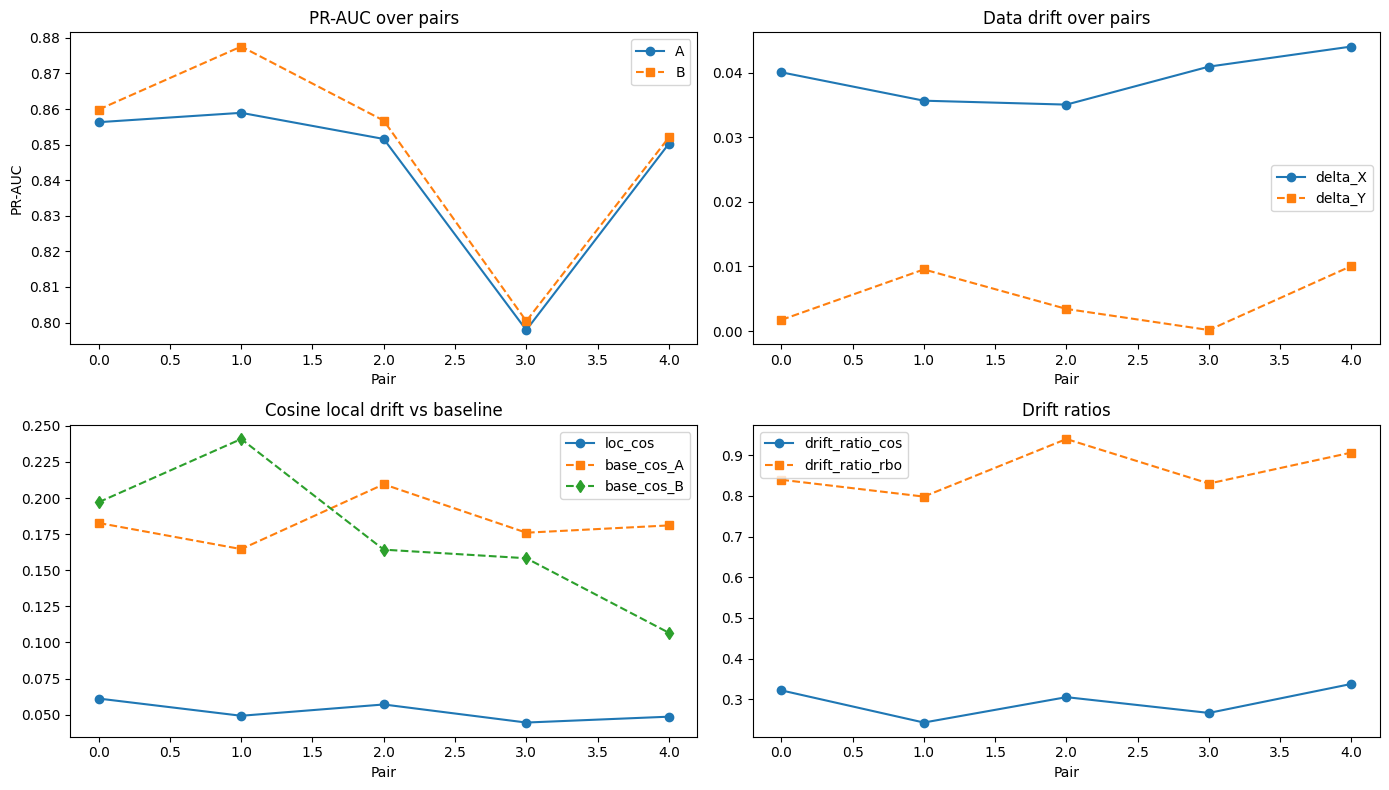

In [8]:
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(drift_df['pair_id'], drift_df['pr_auc_A'], 'o-', label='A')
ax1.plot(drift_df['pair_id'], drift_df['pr_auc_B'], 's--', label='B')
ax1.set_title('PR-AUC over pairs')
ax1.set_xlabel('Pair')
ax1.set_ylabel('PR-AUC')
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(drift_df['pair_id'], drift_df['delta_X'], 'o-', label='delta_X')
ax2.plot(drift_df['pair_id'], drift_df['delta_Y'], 's--', label='delta_Y')
ax2.set_title('Data drift over pairs')
ax2.set_xlabel('Pair')
ax2.legend()

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(drift_df['pair_id'], drift_df['loc_cos'], 'o-', label='loc_cos')
ax3.plot(drift_df['pair_id'], drift_df['base_cos_A'], 's--', label='base_cos_A')
ax3.plot(drift_df['pair_id'], drift_df['base_cos_B'], 'd--', label='base_cos_B')
ax3.set_title('Cosine local drift vs baseline')
ax3.set_xlabel('Pair')
ax3.legend()

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(drift_df['pair_id'], drift_df['drift_ratio_cos'], 'o-', label='drift_ratio_cos')
ax4.plot(drift_df['pair_id'], drift_df['drift_ratio_rbo'], 's--', label='drift_ratio_rbo')
ax4.set_title('Drift ratios')
ax4.set_xlabel('Pair')
ax4.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'drift_summary.png', dpi=120)
plt.show()


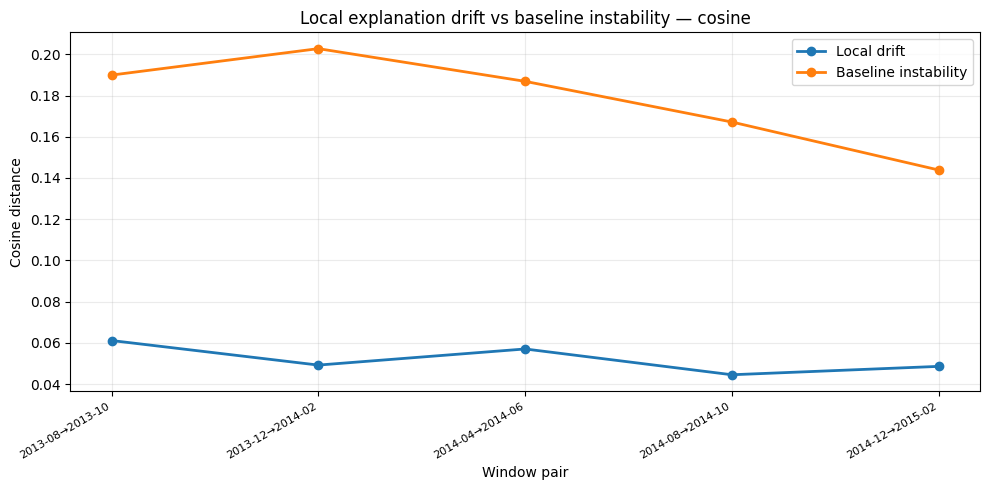

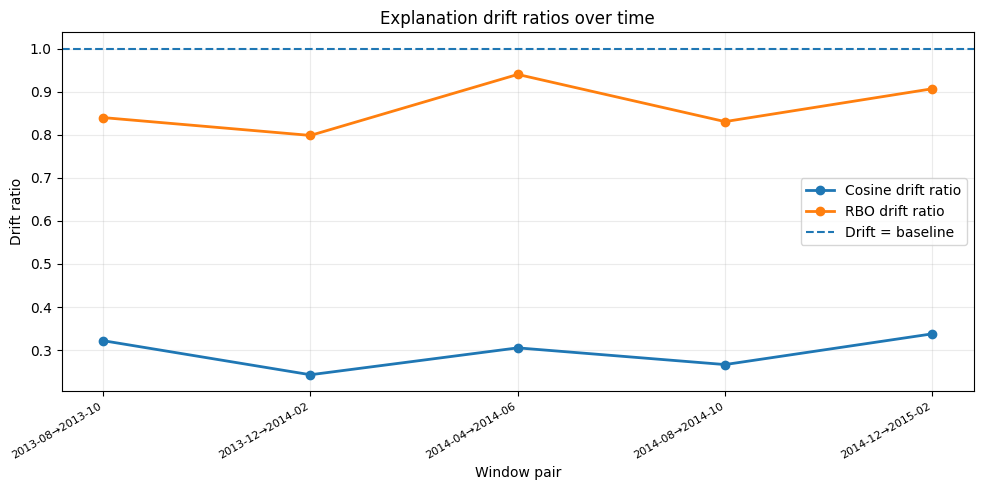

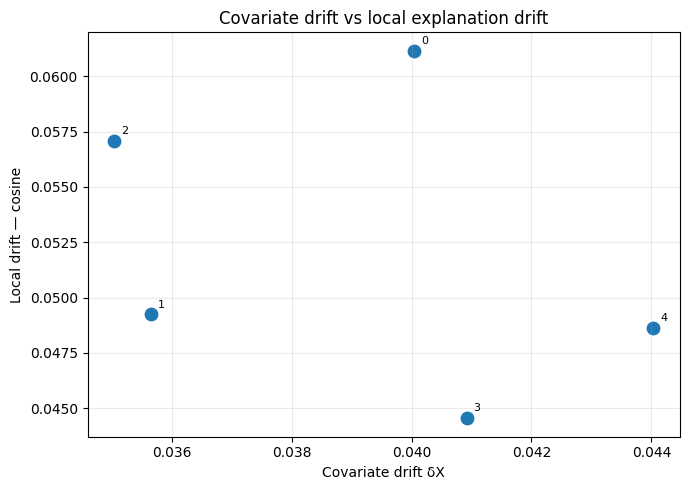

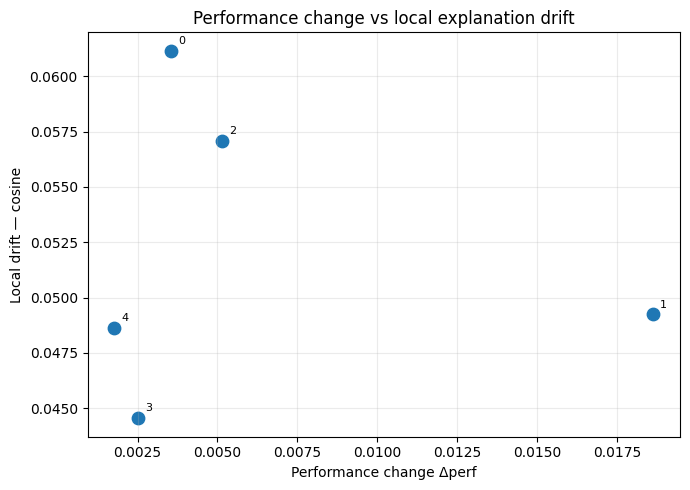

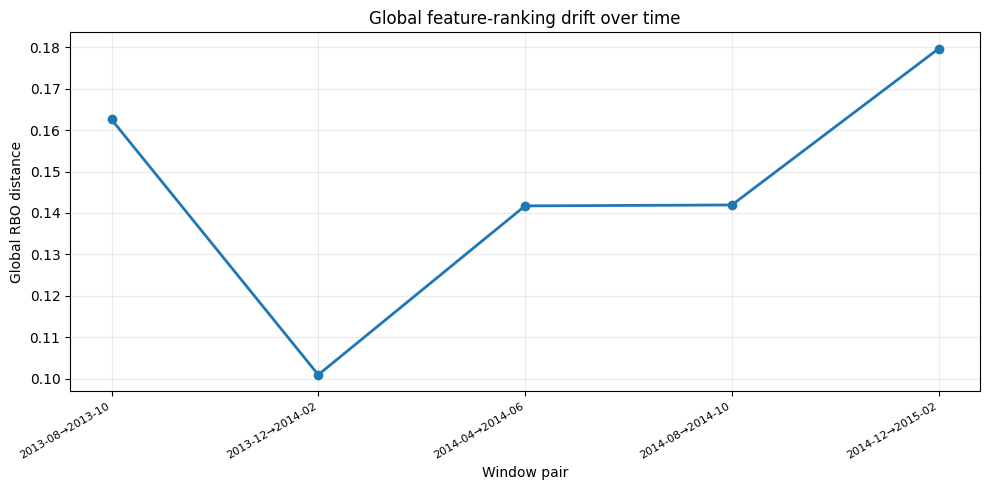

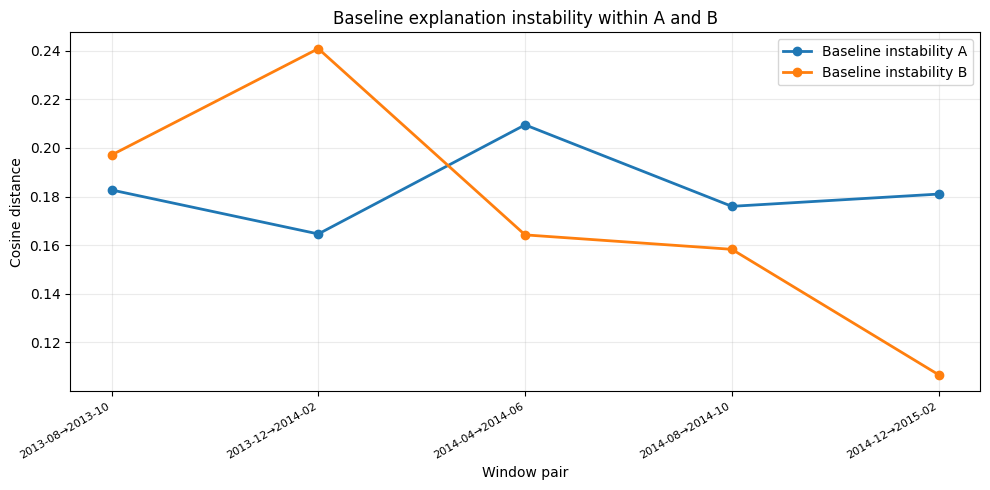

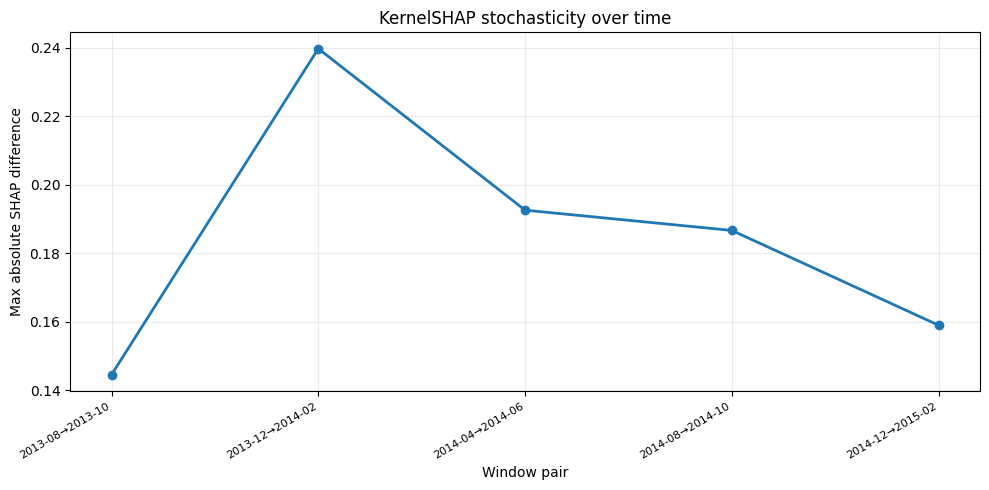

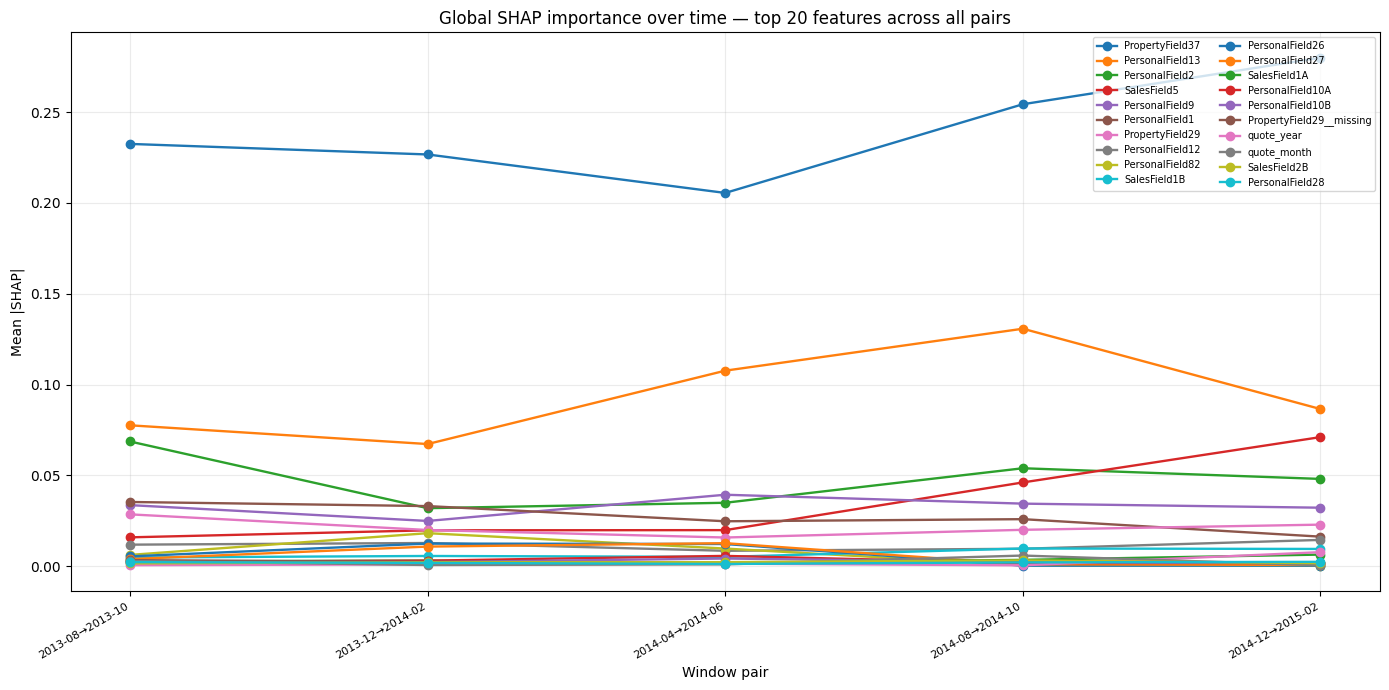

Saved all plots to: /content/drive/MyDrive/Home Insurance MLP/data/results/plots


In [10]:
PLOT_DIR = RESULTS_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plot_df = drift_df.copy()
plot_df["pair_label"] = plot_df["step_label_A"].astype(str) + "→" + plot_df["step_label_B"].astype(str)

x = np.arange(len(plot_df))
labels = plot_df["pair_label"].tolist()

def finish_plot(filename):
    plt.xticks(x, labels, rotation=30, ha="right", fontsize=8)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x, plot_df["loc_cos"], marker="o", linewidth=2, label="Local drift")
plt.plot(x, plot_df["sigma_cos"], marker="o", linewidth=2, label="Baseline instability")
plt.title("Local explanation drift vs baseline instability — cosine")
plt.xlabel("Window pair")
plt.ylabel("Cosine distance")
plt.legend()
finish_plot("01_drift_vs_baseline_cosine.png")

plt.figure(figsize=(10, 5))
plt.plot(x, plot_df["drift_ratio_cos"], marker="o", linewidth=2, label="Cosine drift ratio")
plt.plot(x, plot_df["drift_ratio_rbo"], marker="o", linewidth=2, label="RBO drift ratio")
plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Drift = baseline")
plt.title("Explanation drift ratios over time")
plt.xlabel("Window pair")
plt.ylabel("Drift ratio")
plt.legend()
finish_plot("02_drift_ratios_over_time.png")

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["delta_X"], plot_df["loc_cos"], s=80)
for _, row in plot_df.iterrows():
    plt.annotate(str(row["pair_id"]), (row["delta_X"], row["loc_cos"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.title("Covariate drift vs local explanation drift")
plt.xlabel("Covariate drift δX")
plt.ylabel("Local drift — cosine")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_covariate_drift_vs_explanation_drift.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["delta_perf"], plot_df["loc_cos"], s=80)
for _, row in plot_df.iterrows():
    plt.annotate(str(row["pair_id"]), (row["delta_perf"], row["loc_cos"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.title("Performance change vs local explanation drift")
plt.xlabel("Performance change Δperf")
plt.ylabel("Local drift — cosine")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_performance_change_vs_explanation_drift.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x, plot_df["global_rbo"], marker="o", linewidth=2)
plt.title("Global feature-ranking drift over time")
plt.xlabel("Window pair")
plt.ylabel("Global RBO distance")
finish_plot("05_global_rbo_over_time.png")

plt.figure(figsize=(10, 5))
plt.plot(x, plot_df["base_cos_A"], marker="o", linewidth=2, label="Baseline instability A")
plt.plot(x, plot_df["base_cos_B"], marker="o", linewidth=2, label="Baseline instability B")
plt.title("Baseline explanation instability within A and B")
plt.xlabel("Window pair")
plt.ylabel("Cosine distance")
plt.legend()
finish_plot("06_baseline_instability_A_vs_B.png")

plt.figure(figsize=(10, 5))
plt.plot(x, plot_df["shap_stochasticity"], marker="o", linewidth=2)
plt.title("KernelSHAP stochasticity over time")
plt.xlabel("Window pair")
plt.ylabel("Max absolute SHAP difference")
finish_plot("07_kernelshap_stochasticity.png")

global_imp_matrix = []
pair_labels = []

for p in pairs:
    pid = p["pair_id"]
    shap_dir = SHAP_DIR / f"pair_{pid:02d}"
    shap_A_path = shap_dir / "shap_A.npy"
    shap_B_path = shap_dir / "shap_B.npy"

    if not shap_A_path.exists() or not shap_B_path.exists():
        continue

    shap_A = np.load(shap_A_path)
    shap_B = np.load(shap_B_path)

    phi_bar_A = shap_A.mean(axis=0)
    phi_bar_B = shap_B.mean(axis=0)

    g_pair = 0.5 * (
        np.abs(phi_bar_A).mean(axis=0) +
        np.abs(phi_bar_B).mean(axis=0)
    )

    global_imp_matrix.append(g_pair)
    pair_labels.append(f"{p['step_label_A']}→{p['step_label_B']}")

if len(global_imp_matrix) > 0:
    imp_arr = np.array(global_imp_matrix)
    mean_importance = imp_arr.mean(axis=0)
    top_feat_idx = np.argsort(-mean_importance)[:20]

    plt.figure(figsize=(14, 7))

    for j in top_feat_idx:
        plt.plot(
            range(len(pair_labels)),
            imp_arr[:, j],
            marker="o",
            linewidth=1.7,
            label=feature_names[j]
        )

    plt.title("Global SHAP importance over time — top 20 features across all pairs")
    plt.xlabel("Window pair")
    plt.ylabel("Mean |SHAP|")
    plt.xticks(range(len(pair_labels)), pair_labels, rotation=30, ha="right", fontsize=8)
    plt.legend(loc="upper right", fontsize=7, ncol=2)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "08_feature_importance_over_time_top20.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No SHAP files found for feature-importance plot.")

print(f"Saved all plots to: {PLOT_DIR}")